# Engenharia de Atributos - Top 5 Features
Este notebook implementa as 5 features mais importantes do modelo de previsão de vendas (baseado no notebook Kaggle `e-commerce-sales-forecast` por allunia).

As features extraídas do gráfico de importância (SHAP) são:
1. `PreChristmasMeanQuantity`
2. `KnownStockCodePrice_WW_std`
3. `KnownStockCodeUnitPriceMedian`
4. `KnownStockCodePrice_WW_mean`
5. `KnownStockCodePrice_WW_median`

Abaixo vamos reconstruí-las cuidadosamente para **evitar Data Leakage** (vazamento de dados), garantindo que as estatísticas passadas não espionem os dados futuros.

## Importação e Preparação Inicial
Primeiro, vamos carregar os dados limpos, ajustar os tipos de dados e fazer a ordenação cronológica fundamental para a engenharia de séries temporais.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('cleaned_online_retail_II.csv')

# Convertendo a coluna Date para datetime
df['Date'] = pd.to_datetime(df['Date'])

# Ordenação cronológica fundamental para evitar Data Leakage
df = df.sort_values('Date').reset_index(drop=True)
df['Year'] = df['Date'].dt.year
df.head()

,InvoiceNo,InvoiceDate,Date,Year,Month,Day,Quarter,Week,Weekday,DayOfYear,StockCode,CustomerID,Country,Description,UnitPrice,Quantity,Revenue
0,489434,2009-12-01 07:45:00,2009-12-01,2009,12,1,4,49,1,335,21232,13085.0,United Kingdom,STRAWBERRY CERAMIC TRINKET BOX,1.25,24,30.00
1,489574,2009-12-01 13:31:00,2009-12-01,2009,12,1,4,49,1,335,21745,13097.0,United Kingdom,GAOLERS KEYS DECORATIVE GARDEN,3.75,4,15.00
2,489574,2009-12-01 13:31:00,2009-12-01,2009,12,1,4,49,1,335,21741,13097.0,United Kingdom,COSY SLIPPER SHOES LARGE GREEN,2.95,3,8.85
3,489574,2009-12-01 13:31:00,2009-12-01,2009,12,1,4,49,1,335,21740,13097.0,United Kingdom,COSY SLIPPER SHOES LARGE RED,2.95,3,8.85
4,489574,2009-12-01 13:31:00,2009-12-01,2009,12,1,4,49,1,335,21554,13097.0,United Kingdom,CERAMIC BIRDHOUSE RED ROOF LARGE,5.95,1,5.95


## 1. Feature: PreChristmasMeanQuantity
Esta variável mede a média de itens vendidos durante o período de compras pré-Natal (novembro até 24 de dezembro).

Para que o modelo não use o futuro para prever o passado, calculamos essa média por `StockCode` agrupado por `Year` e **deslocamos o ano em +1** (+ 1 year shift). Dessa forma, a média calculada no Natal de 2010 será aplicada como *feature* preditiva para as datas de 2011.

In [2]:
print("Calculando PreChristmasMeanQuantity (sem data leakage)...")
df['PreChristmas'] = ((df['Date'].dt.month == 11) | ((df['Date'].dt.month == 12) & (df['Date'].dt.day <= 24)))

pre_christmas_qty = df[df['PreChristmas']].groupby(['StockCode', 'Year'])['Quantity'].mean().reset_index()
pre_christmas_qty.rename(columns={'Quantity': 'PreChristmasMeanQuantity'}, inplace=True)

# Adiciona 1 ao ano para garantir que a média do ano passado seja usada no ano atual
pre_christmas_qty['Year'] = pre_christmas_qty['Year'] + 1
df = df.merge(pre_christmas_qty, on=['StockCode', 'Year'], how='left')

# Valores do primeiro ano e produtos que não venderam no Natal passado recebem 0
df['PreChristmasMeanQuantity'] = df['PreChristmasMeanQuantity'].fillna(0)
df.drop(columns=['PreChristmas', 'Year'], inplace=True)

Calculando PreChristmasMeanQuantity (sem data leakage)...


## 2. Feature: KnownStockCodeUnitPriceMedian
Aqui encontramos o preço histórico típico de cada item (`StockCode`).

Para preservar a restrição temporal, utilizamos uma **Janela Expansiva (Expanding Window)** e a função `shift(1)`. O cálculo percorre o tempo acumulando os preços até o dia $T-1$, isolando a mediana.

In [3]:
print("Calculando KnownStockCodeUnitPriceMedian (expanding window)...")

# Calcula a mediana acumulada até o registro atual e faz o shift(1) para usar apenas dados passados
df['KnownStockCodeUnitPriceMedian'] = (
    df.groupby('StockCode')['UnitPrice']
    .transform(lambda x: x.expanding().median().shift(1))
)

# Na primeira venda do produto (histórico vazio = NaN), imputamos o preço base da transação atual
df['KnownStockCodeUnitPriceMedian'] = df['KnownStockCodeUnitPriceMedian'].fillna(df['UnitPrice'])

Calculando KnownStockCodeUnitPriceMedian (expanding window)...


## 3, 4 e 5. Features WW (Week-Weekday)
Neste passo, criamos estatísticas (`mean`, `median`, `std`) do preço considerando especificamente o agrupamento de `Week` (Semana do ano) e `Weekday` (Dia da semana).

As transformações cumulativas e o atraso (`shift`) aplicados isolam a temporalidade e mantêm os preços anteriores de dias correspondentes passados.

In [4]:
print("Calculando features WW (Week-Weekday) para Price (expanding window)...")

# Usamos o agrupamento definido mas calculamos com expansão e shift para evitar vazamento
ww_groups = df.groupby(['StockCode', 'Week', 'Weekday'])['UnitPrice']

df['KnownStockCodePrice_WW_mean'] = ww_groups.transform(lambda x: x.expanding().mean().shift(1)).fillna(df['UnitPrice'])
df['KnownStockCodePrice_WW_median'] = ww_groups.transform(lambda x: x.expanding().median().shift(1)).fillna(df['UnitPrice'])
df['KnownStockCodePrice_WW_std'] = ww_groups.transform(lambda x: x.expanding().std().shift(1)).fillna(0)

Calculando features WW (Week-Weekday) para Price (expanding window)...


## Resultado Final
Com as top 5 features aplicadas e protegidas contra *data leakage*, o dataset já possui os atributos essenciais listados pelo SHAP.

In [5]:
print("Features criadas com sucesso!")
cols_to_show = ['StockCode', 'Date', 'PreChristmasMeanQuantity', 'KnownStockCodeUnitPriceMedian', 
                'KnownStockCodePrice_WW_mean', 'KnownStockCodePrice_WW_median', 'KnownStockCodePrice_WW_std']
display(df[cols_to_show].head(10))

# Para salvar o dataset final descomente a linha abaixo:
# df.to_csv('cleaned_online_retail_II_features.csv', index=False)

Features criadas com sucesso!


,StockCode,Date,PreChristmasMeanQuantity,KnownStockCodeUnitPriceMedian,KnownStockCodePrice_WW_mean,KnownStockCodePrice_WW_median,KnownStockCodePrice_WW_std
0,21232,2009-12-01,0.0,1.25,1.25,1.25,0.0
1,21745,2009-12-01,0.0,3.75,3.75,3.75,0.0
2,21741,2009-12-01,0.0,2.95,2.95,2.95,0.0
3,21740,2009-12-01,0.0,2.95,2.95,2.95,0.0
4,21554,2009-12-01,0.0,5.95,5.95,5.95,0.0
5,21553,2009-12-01,0.0,5.95,5.95,5.95,0.0
6,21548,2009-12-01,0.0,2.95,2.95,2.95,0.0
7,21547,2009-12-01,0.0,2.95,2.95,2.95,0.0
8,21534,2009-12-01,0.0,4.95,4.95,4.95,0.0
9,21524,2009-12-01,0.0,6.75,6.75,6.75,0.0


## Testando as Features (Gráfico de Importância)
Já que construímos as features, vamos treinar um modelo rápido (Random Forest) apenas para validar a importância dessas variáveis (exatamente como o gráfico que você viu no Kaggle!).
Como a função `model.show_importances()` do Kaggle era um atalho customizado da autora, usaremos a forma nativa do Scikit-Learn e do Pandas.

Preparando os dados para o modelo...
Treinando o RandomForestRegressor (isso pode levar alguns segundos)...
Plotando as importâncias das variáveis...


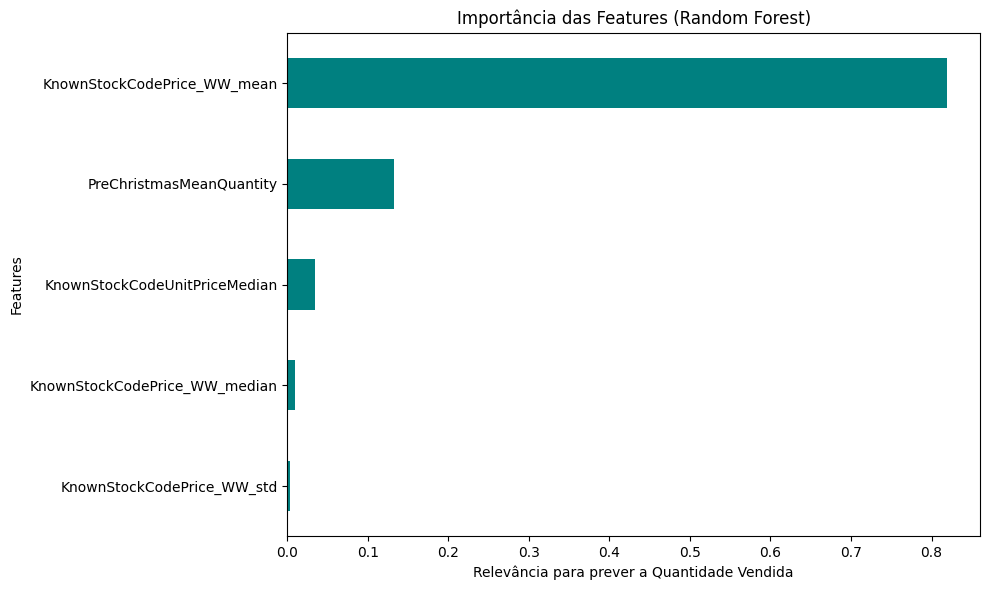

In [6]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

print("Preparando os dados para o modelo...")
# Selecionamos as features que criamos
features = [
    'PreChristmasMeanQuantity',
    'KnownStockCodeUnitPriceMedian',
    'KnownStockCodePrice_WW_mean',
    'KnownStockCodePrice_WW_median',
    'KnownStockCodePrice_WW_std'
]

# O alvo da previsão geralmente é a quantidade atual vendida (Quantity) ou a Receita
target = 'Quantity'

# Limpamos as linhas que possam ter ficado com algum NaN por segurança antes do treino
df_model = df[features + [target]].dropna()

print("Treinando o RandomForestRegressor (isso pode levar alguns segundos)...")
# Treinando uma Árvore de Decisão Rápida (10 estimadores para rodar rápido)
model = RandomForestRegressor(n_estimators=10, random_state=42, max_depth=5)
model.fit(df_model[features], df_model[target])

print("Plotando as importâncias das variáveis...")
# Extraindo a importância de cada feature (substituindo a função customizada do Kaggle)
importancias = pd.Series(model.feature_importances_, index=features)

# Plotando o gráfico
plt.figure(figsize=(10, 6))
importancias.sort_values().plot(kind='barh', color='teal')
plt.title('Importância das Features (Random Forest)')
plt.xlabel('Relevância para prever a Quantidade Vendida')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


/home/pk/studing/projects/machine_learning/revenue_estimate/eniac/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calculando valores SHAP e gerando o gráfico...


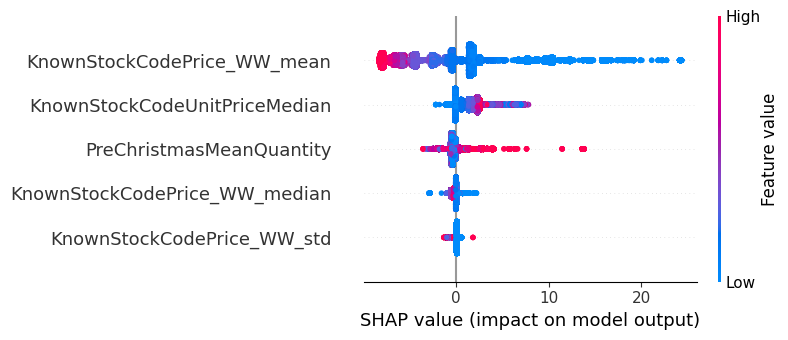

In [7]:
import shap

print("Calculando valores SHAP e gerando o gráfico...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df_model[features])

shap.summary_plot(shap_values, df_model[features])


In [8]:
df.to_csv('cleaned_online_retail_II_features.csv', index=False)
df

,InvoiceNo,InvoiceDate,Date,Month,Day,Quarter,Week,Weekday,DayOfYear,StockCode,...,Country,Description,UnitPrice,Quantity,Revenue,PreChristmasMeanQuantity,KnownStockCodeUnitPriceMedian,KnownStockCodePrice_WW_mean,KnownStockCodePrice_WW_median,KnownStockCodePrice_WW_std
0,489434,2009-12-01 07:45:00,2009-12-01,12,1,4,49,1,335,21232,...,United Kingdom,STRAWBERRY CERAMIC TRINKET BOX,1.25,24,30.00,0.000000,1.25,1.250000,1.25,0.000000
1,489574,2009-12-01 13:31:00,2009-12-01,12,1,4,49,1,335,21745,...,United Kingdom,GAOLERS KEYS DECORATIVE GARDEN,3.75,4,15.00,0.000000,3.75,3.750000,3.75,0.000000
2,489574,2009-12-01 13:31:00,2009-12-01,12,1,4,49,1,335,21741,...,United Kingdom,COSY SLIPPER SHOES LARGE GREEN,2.95,3,8.85,0.000000,2.95,2.950000,2.95,0.000000
3,489574,2009-12-01 13:31:00,2009-12-01,12,1,4,49,1,335,21740,...,United Kingdom,COSY SLIPPER SHOES LARGE RED,2.95,3,8.85,0.000000,2.95,2.950000,2.95,0.000000
4,489574,2009-12-01 13:31:00,2009-12-01,12,1,4,49,1,335,21554,...,United Kingdom,CERAMIC BIRDHOUSE RED ROOF LARGE,5.95,1,5.95,0.000000,5.95,5.950000,5.95,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322971,538015,2010-12-09 12:49:00,2010-12-09,12,9,4,49,3,343,22113,...,United Kingdom,GREY HEART HOT WATER BOTTLE,3.75,3,11.25,5.915493,3.75,3.657692,3.75,0.144115
322972,538015,2010-12-09 12:49:00,2010-12-09,12,9,4,49,3,343,21745,...,United Kingdom,GAOLERS KEYS DECORATIVE GARDEN,3.75,3,11.25,1.900000,3.75,3.750000,3.75,0.000000
322973,538015,2010-12-09 12:49:00,2010-12-09,12,9,4,49,3,343,21730,...,United Kingdom,GLASS STAR FROSTED T-LIGHT HOLDER,4.95,3,14.85,3.347826,4.95,4.950000,4.95,0.000000
322974,538015,2010-12-09 12:49:00,2010-12-09,12,9,4,49,3,343,85107,...,United Kingdom,CUT GLASS T-LIGHT HOLDER OCTAGON,2.55,12,30.60,12.857143,2.55,2.550000,2.55,0.000000
